In [9]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)

TRAIN_PATH  = os.path.join('data_split', 'train')
VAL_PATH    = os.path.join('data_split', 'val')
TEST_PATH   = os.path.join('data_split', 'test')
IMG_SIZE    = (100, 100)
BATCH_SIZE  = 32
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

train_datagen    = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)
val_generator = val_test_datagen.flow_from_directory(
    VAL_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
print("Generators ready!")

Found 11920 images belonging to 6 classes.
Found 2552 images belonging to 6 classes.
Found 2562 images belonging to 6 classes.
Generators ready!


In [10]:
def build_scratch_cnn():
    model = models.Sequential(name="CNN_From_Scratch")
    model.add(layers.Input(shape=(100, 100, 3)))

    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(6, activation='softmax'))

    return model

scratch_model = build_scratch_cnn()
scratch_model.summary()

Model: "CNN_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 100, 100, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 100, 100, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 100, 100, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 100, 100, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 50, 50, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 50, 50, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 50, 50, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 50, 50, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 50, 50, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 50, 50, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 25, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 25, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 25, 25, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 25, 25, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 25, 25, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 25, 25, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 5,436,966 (20.74 MB)

 Trainable params: 5,435,558 (20.74 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [11]:
scratch_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

scratch_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'models/scratch_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        verbose=1,
        min_lr=1e-7
    )
]

start = time.time()
history_scratch = scratch_model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=scratch_callbacks,
    verbose=1
)
scratch_time = time.time() - start
print(f"\nScratch CNN training finished in {scratch_time/60:.1f} minutes")

Epoch 1/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.3739 - loss: 3.0940
Epoch 1: val_loss improved from None to 1.43670, saving model to models/scratch_best.keras

Epoch 1: finished saving model to models/scratch_best.keras
373/373 ━━━━━━━━━━━━━━━━━━━━ 302s 797ms/step - accuracy: 0.4268 - loss: 2.0901 - val_accuracy: 0.3766 - val_loss: 1.4367 - learning_rate: 0.0010
Epoch 2/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.5045 - loss: 1.3522
Epoch 2: val_loss improved from 1.43670 to 1.11323, saving model to models/scratch_best.keras

Epoch 2: finished saving model to models/scratch_best.keras
373/373 ━━━━━━━━━━━━━━━━━━━━ 334s 830ms/step - accuracy: 0.5273 - loss: 1.2682 - val_accuracy: 0.5976 - val_loss: 1.1132 - learning_rate: 0.0010
Epoch 3/25
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.5856 - loss: 1.1171
Epoch 3: val_loss improved from 1.11323 to 0.85959, saving model to models/scratch_best.keras

Epoch 3: finished saving model to models/scr

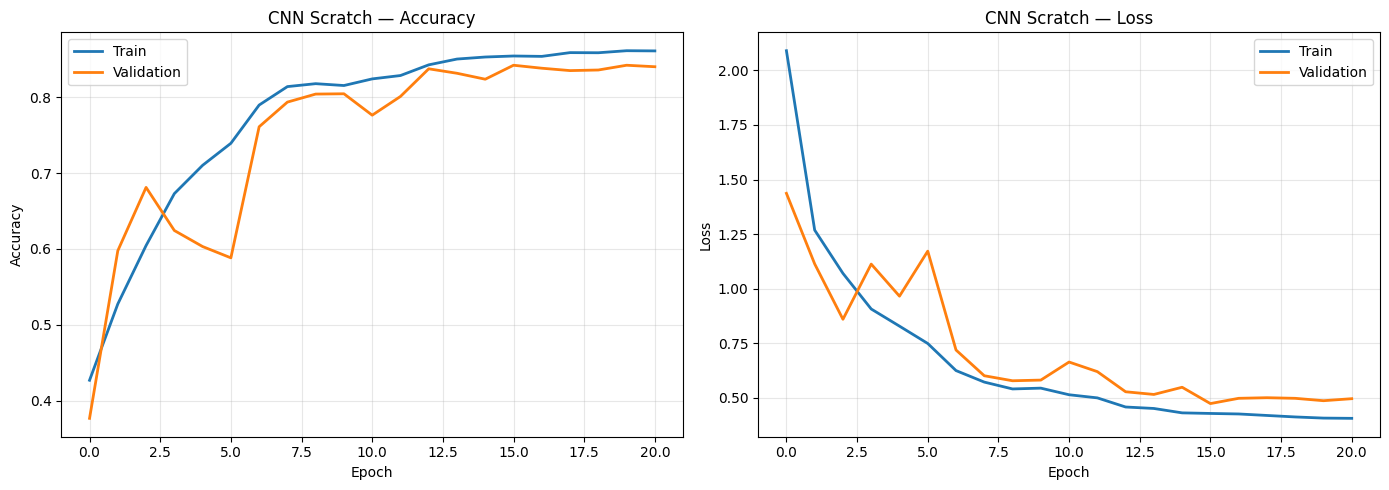

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_scratch.history['accuracy'],     label='Train', linewidth=2)
ax1.plot(history_scratch.history['val_accuracy'], label='Validation', linewidth=2)
ax1.set_title('CNN Scratch — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_scratch.history['loss'],     label='Train', linewidth=2)
ax2.plot(history_scratch.history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('CNN Scratch — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/scratch_curves.png', dpi=150)
plt.show()

81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step
SCRATCH CNN — Classification Report
              precision    recall  f1-score   support

   buildings       0.90      0.82      0.86       395
      forest       0.83      0.99      0.90       413
     glacier       0.85      0.67      0.75       445
    mountain       0.75      0.85      0.80       457
         sea       0.82      0.91      0.86       419
      street       0.89      0.78      0.83       433

    accuracy                           0.83      2562
   macro avg       0.84      0.84      0.83      2562
weighted avg       0.84      0.83      0.83      2562



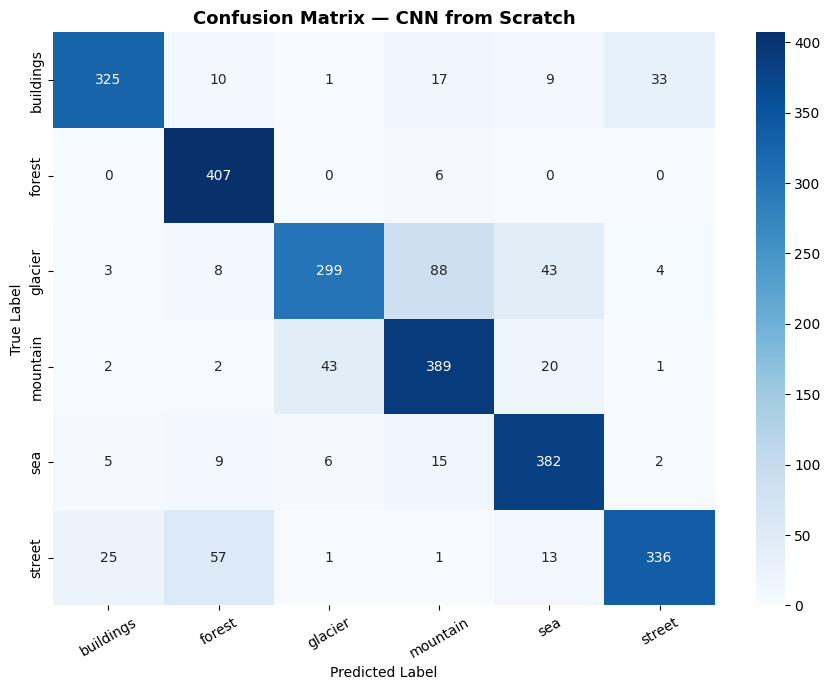

Trainable parameters: 5,436,966
Results saved for comparison notebook!


In [13]:
import json

test_generator.reset()
scratch_preds = np.argmax(scratch_model.predict(test_generator, verbose=1), axis=1)
y_true = test_generator.classes

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("SCRATCH CNN — Classification Report")
print(classification_report(y_true, scratch_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, scratch_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — CNN from Scratch', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('results/scratch_confusion_matrix.png', dpi=150)
plt.show()

np.save('results/scratch_preds.npy',  scratch_preds)
np.save('results/y_true.npy',         y_true)
np.save('results/scratch_time.npy',   [scratch_time])
np.save('results/scratch_params.npy', [scratch_model.count_params()])
print(f"Trainable parameters: {scratch_model.count_params():,}")

history_to_save = {
    'accuracy':     history_scratch.history['accuracy'],
    'val_accuracy': history_scratch.history['val_accuracy'],
    'loss':         history_scratch.history['loss'],
    'val_loss':     history_scratch.history['val_loss'],
}
with open('results/scratch_history.json', 'w') as f:
    json.dump(history_to_save, f)

print("Results saved for comparison notebook!")